**<div style='text-align: center; font-size: 48px'><u>Experiment 2 : Data Wrangling 2</u></div>**
### <div align="center"> Name : Shravan Santosh Shidruk , PRN : 72311412K </div>
### <div align="center"> Dataset Used : [Students Performance in Exams Dataset](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams) </div>
---
### <div align="center"> Dataset Description </div>

The dataset used is the “Students Performance in Exams” dataset obtained from Kaggle. It contains information about student performance in subjects like mathematics, reading, and writing, along with demographic and socio-economic factors such as gender, parental education level, and lunch type.

Source: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

This dataset is suitable for data wrangling as it includes both categorical and numerical variables, allowing analysis of missing values, outliers, and data transformations.

<b> Variable Descriptions: </b>
The dataset contains the following variables:

* gender: Gender of the student (Categorical)
* race/ethnicity: Ethnic group of the student (Categorical)
* parental level of education: Highest education level of parents (Categorical)
* lunch: Type of lunch (standard or free/reduced) (Categorical)
* test preparation course: Whether the student completed a test preparation course (Categorical)
* math score: Marks obtained in Mathematics (Numeric)
* reading score: Marks obtained in Reading (Numeric)
* writing score: Marks obtained in Writing (Numeric)
---

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv("StudentsPerformance.csv")

### 1. Check dataset for **Missing Values** , **Duplicates** and **Inconsistencies**

In [36]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [37]:
print(f"Shape of dataset is : {df.shape[0]} rows , {df.shape[1]} columns with {df.shape[0]*df.shape[1]} values")

Shape of dataset is : 1000 rows , 8 columns with 8000 values


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [39]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [40]:
print("Total missing values are : ",df.isnull().sum().sum())
print("Total missing values per column are :\n",df.isnull().sum())

Total missing values are :  0
Total missing values per column are :
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


### Handling Missing Values

In [41]:
print("Missing values before:\n", df.isnull().sum())
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
print("Missing values after:\n", df.isnull().sum())

Missing values before:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
Missing values after:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


### Handling Duplicate Values

In [42]:
print("Duplicate rows before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


### 2. Check for Outliers

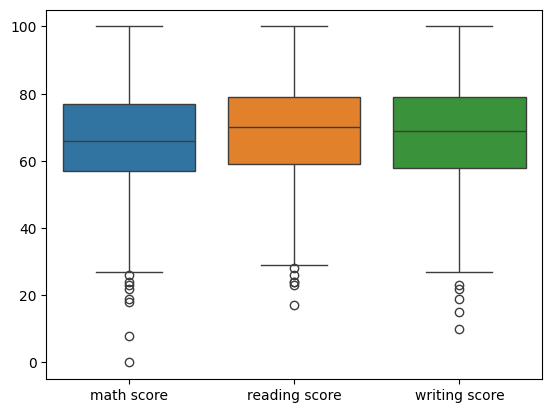

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df)
plt.show()

### 3. Removing Outliers

In [44]:
def remove_outlier(df, col_name):
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[(df[col_name] >= lower_bound) & (df[col_name] <= upper_bound)]

print(f"Shape before outlier removal: {df.shape}")

for col in df.select_dtypes(include='number').columns:
    df = remove_outlier(df, col)

print(f"Shape after outlier removal: {df.shape}")

Shape before outlier removal: (1000, 8)
Shape after outlier removal: (986, 8)


### 4. Data Transformation

#### 4.1 : Current Distribution

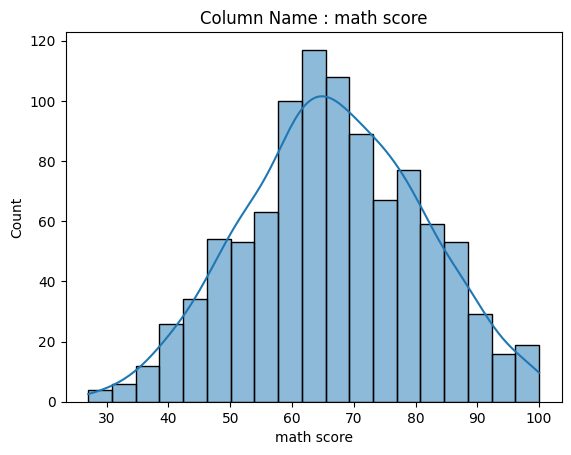

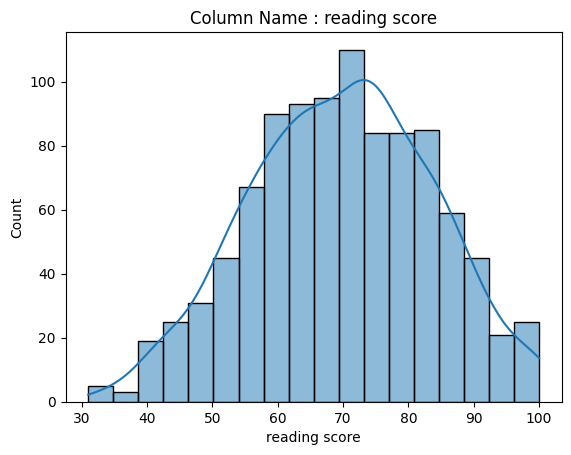

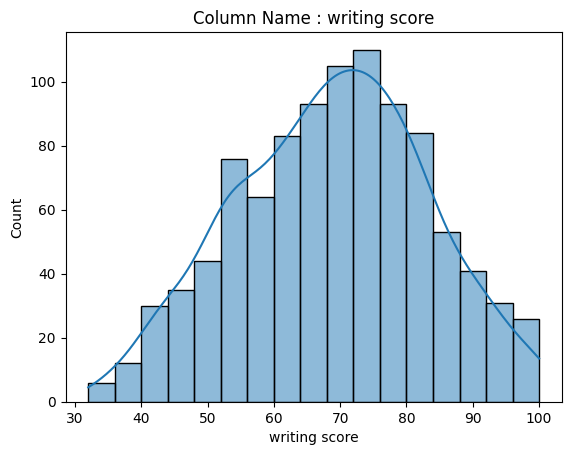

In [45]:
for col in df.select_dtypes('number').columns:
    sns.histplot(df[col],kde=True)
    plt.title(f"Column Name : {col}")
    plt.show()

#### 4.2 : Applied log transformation to reduce skewness

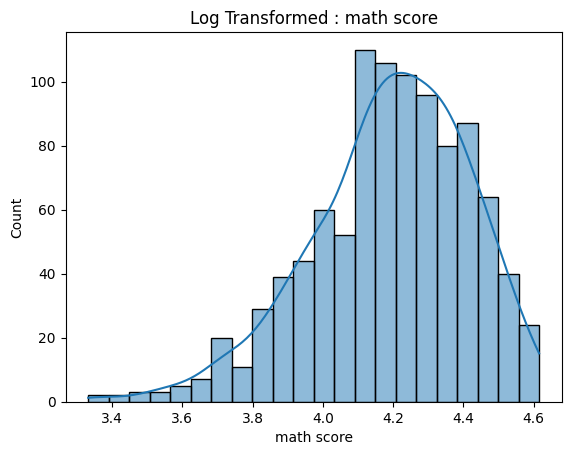

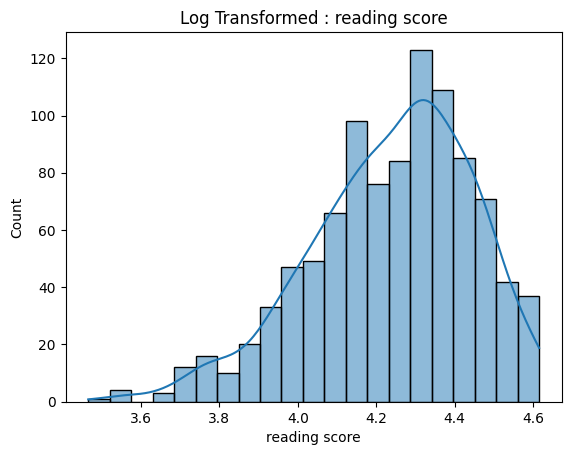

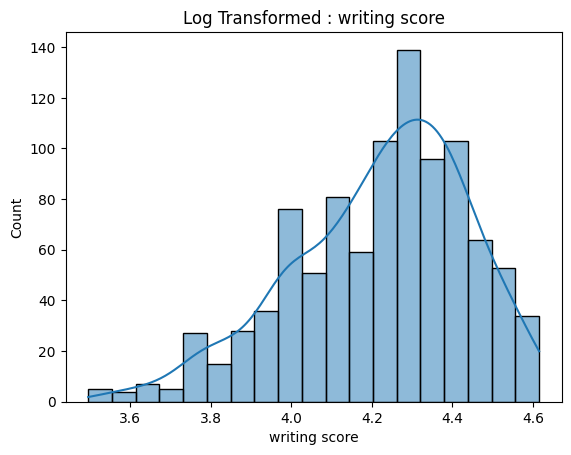

In [46]:
for col in df.select_dtypes('number').columns:
    sns.histplot(np.log1p(df[col]),kde=True)
    plt.title(f"Log Transformed : {col}")
    plt.show()

## Conclusion
### 1. Missing Values 
Missing values are handled using:
- Mean for numerical columns (to preserve distribution)
- Mode for categorical columns (most frequent value)
### 2. Outliers 
- Outliers are detected using the IQR method.
- Any value outside the range : [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] is treated as an outlier and removed.
### 3. Transformation
- Log transformation is applied to reduce skewness and convert non-linear distribution into approximately normal distribution.